# Project 6 -- Niharika Rai

**TA Help:** (for instance) John Smith, Alice Jones, etc., list names of any TAs who helped you

- For example: Help with figuring out how to write a function (describe the tasks that they helped you with)

**Collaboration:** My Friend in CS, My Uncle, Another Student, etc., list names of any other people who helped you

(describe the tasks that they helped you with)
- For example: helped figuring out how to load the dataset.
- Another example: helped debug error with my plot.

**Internet Resources:** Stack Exchange, Stack Overflow, etc.

(describe any information that you learned from internet resources, including the URLs)
- data frames in Pandas versus R from StackOverflow  https://stackoverflow.com/questions/8991709/why-were-pandas-merges-in-python-faster-than-data-table-merges-in-r-in-2012

**ChatGPT, Gemini, Claude, etc:** Any language models or generative AI chatbots that helped you.

(if you used any such tools, please tell us here)
- For example:  I asked ChatGPT how to define a new data frames
- Another example:  Gemini told me how to make a function for sorting my data

- ***Link to AI Chat History***: Please share a link to your chat if you used AI (ex. ChatGPT Shared Links). Here is the link to AI Chat History: https://chatgpt.com/share/69a6123a-0ec4-800d-b17b-76e3a6a1d4ae 
**OVERALL MESSAGE:** Any time that you used anything except your brain to solve the questions in these projects, you need to disclose such resources at the start of the project, with details about your usage of the tools.

**YOUR OWN WORK:** Even when you utilize other resources, do NOT just copy and paste.  Write all explanations in your own words, using several sentences in English, which are understandable and which you wrote (and did not just copy and paste).

## Question 1

In [1]:
import polars as pl

df = pl.read_parquet('/anvil/projects/tdm/data/taxi/yellow_2025/yellow_tripdata_2025-09.parquet')
df.head()

VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
i32,datetime[μs],datetime[μs],i64,f64,i64,str,i32,i32,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2,2025-09-01 00:19:20,2025-09-01 00:45:17,1,9.92,1,"""N""",138,114,1,42.9,6.0,0.5,10.73,0.0,1.0,66.13,2.5,1.75,0.75
2,2025-09-01 00:15:20,2025-09-01 00:26:08,2,6.82,1,"""N""",93,157,1,26.8,1.0,0.5,5.86,0.0,1.0,35.16,0.0,0.0,0.0
2,2025-09-01 00:06:07,2025-09-01 00:22:23,1,3.95,1,"""N""",68,13,1,19.8,1.0,0.5,5.11,0.0,1.0,30.66,2.5,0.0,0.75
2,2025-09-01 00:49:47,2025-09-01 01:04:49,1,3.14,1,"""N""",234,87,1,17.7,1.0,0.5,3.52,0.0,1.0,26.97,2.5,0.0,0.75
2,2025-09-01 00:05:00,2025-09-01 00:15:32,6,2.81,1,"""N""",230,151,1,14.9,1.0,0.5,4.13,0.0,1.0,24.78,2.5,0.0,0.75


In [2]:
df.select(
    mean=pl.col('total_amount').mean(),
    std=pl.col('total_amount').std(),
    median=pl.col('total_amount').median(),
    min1=pl.col('total_amount').min(),
    max1=pl.col('total_amount').max()
    )

mean,std,median,min1,max1
f64,f64,f64,f64,f64
27.713274,158.873551,22.15,-1002.25,323820.17


In [3]:
df.select(
    pl.col('total_amount')
).describe()

statistic,total_amount
str,f64
"""count""",4.251015e6
"""null_count""",0.0
"""mean""",27.713274
"""std""",158.873551
"""min""",-1002.25
"""25%""",16.32
"""50%""",22.15
"""75%""",31.82
"""max""",323820.17


In [4]:
df.select(
    trip_duration=(pl.col('tpep_dropoff_datetime') - pl.col('tpep_pickup_datetime')).dt.total_minutes()
)

trip_duration
i64
25
10
16
15
10
…
11
21
19


In [5]:
df.with_columns(
    trip_duration=(pl.col('tpep_dropoff_datetime') - pl.col('tpep_pickup_datetime')).dt.total_minutes()
)

VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,trip_duration
i32,datetime[μs],datetime[μs],i64,f64,i64,str,i32,i32,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64
2,2025-09-01 00:19:20,2025-09-01 00:45:17,1,9.92,1,"""N""",138,114,1,42.9,6.0,0.5,10.73,0.0,1.0,66.13,2.5,1.75,0.75,25
2,2025-09-01 00:15:20,2025-09-01 00:26:08,2,6.82,1,"""N""",93,157,1,26.8,1.0,0.5,5.86,0.0,1.0,35.16,0.0,0.0,0.0,10
2,2025-09-01 00:06:07,2025-09-01 00:22:23,1,3.95,1,"""N""",68,13,1,19.8,1.0,0.5,5.11,0.0,1.0,30.66,2.5,0.0,0.75,16
2,2025-09-01 00:49:47,2025-09-01 01:04:49,1,3.14,1,"""N""",234,87,1,17.7,1.0,0.5,3.52,0.0,1.0,26.97,2.5,0.0,0.75,15
2,2025-09-01 00:05:00,2025-09-01 00:15:32,6,2.81,1,"""N""",230,151,1,14.9,1.0,0.5,4.13,0.0,1.0,24.78,2.5,0.0,0.75,10
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2,2025-09-30 23:18:25,2025-09-30 23:29:31,null,1.38,null,null,186,162,0,12.24,0.0,0.5,0.0,0.0,1.0,16.99,null,null,0.75,11
2,2025-09-30 23:10:38,2025-09-30 23:32:25,null,3.86,null,null,140,114,0,-4.75,0.0,0.5,0.0,0.0,1.0,3.0,null,null,0.75,21
2,2025-09-30 23:20:47,2025-09-30 23:40:36,null,4.01,null,null,256,107,0,-4.75,0.0,0.5,0.0,0.0,1.0,2.83,null,null,0.75,19


In [6]:
df.filter(
    (pl.col('trip_distance') > 5) & (pl.col('passenger_count') > 1)
)

VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
i32,datetime[μs],datetime[μs],i64,f64,i64,str,i32,i32,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2,2025-09-01 00:15:20,2025-09-01 00:26:08,2,6.82,1,"""N""",93,157,1,26.8,1.0,0.5,5.86,0.0,1.0,35.16,0.0,0.0,0.0
2,2025-09-01 00:18:30,2025-09-01 00:41:13,4,9.24,1,"""N""",138,98,2,39.4,6.0,0.5,0.0,0.0,1.0,48.65,0.0,1.75,0.0
2,2025-09-01 00:05:20,2025-09-01 00:26:23,2,8.01,1,"""N""",138,256,2,35.2,6.0,0.5,0.0,0.0,1.0,44.45,0.0,1.75,0.0
2,2025-09-01 00:14:41,2025-09-01 00:33:17,2,6.3,1,"""N""",261,140,1,28.9,1.0,0.5,3.46,0.0,1.0,38.11,2.5,0.0,0.75
2,2025-09-01 00:36:27,2025-09-01 01:23:10,2,17.77,1,"""N""",132,190,1,73.7,1.0,0.5,6.0,0.0,1.0,83.95,0.0,1.75,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2,2025-09-30 23:34:14,2025-10-01 00:32:58,2,18.08,1,"""N""",132,211,2,83.5,1.0,0.5,0.0,0.0,1.0,91.0,2.5,1.75,0.75
2,2025-09-30 23:46:29,2025-10-01 00:10:42,2,9.84,1,"""N""",249,228,2,40.8,1.0,0.5,0.0,0.0,1.0,46.55,2.5,0.0,0.75
2,2025-09-30 23:31:26,2025-10-01 00:33:15,2,17.32,2,"""N""",132,230,1,70.0,0.0,0.5,5.0,6.94,1.0,88.44,2.5,1.75,0.75


1a. I used the sample code in the question to display the first 5 rows along with the shape of the dataframe. 

1b. I used the sample code in the question display the outputs of the mean, standard deviation and describe functions. However, I added my own code lines to the sample code to calculate the median, min and max statistics. I used the link given in the question to apply relevant statistical functions such as median(), min() and max(). Here is the documentation link: https://docs.pola.rs/api/python/stable/reference/dataframe/index.html 

1c. I used the sample code in the question to create the 'trip_duration' column and add it to the dataframe. 

1d. I used the sample code in the question to filter trips with distance > 5 and passengers > 1, with resulting shape.

1e. The main syntax difference is that in Polars, we do not directly index onto the dataframe like we do in Pandas, instead we tell Polars what columns to use and what operations to apply to those columns. Then, we apply these operations to the dataset using the .select() method. 

## Question 2

In [7]:
tip_percent_expr = (pl.col('tip_amount') / pl.col('total_amount')) * 100
tip_percent_expr

<Expr ['[([(col("tip_amount")) / (col(…'] at 0x7F4F9A135550>

In [8]:
df.select(
    pl.col('total_amount'),
    tip_percent=tip_percent_expr
)

total_amount,tip_percent
f64,f64
66.13,16.225616
35.16,16.666667
30.66,16.666667
26.97,13.051539
24.78,16.666667
…,…
16.99,0.0
3.0,0.0
2.83,0.0


In [9]:
df.select(
    pl.col('total_amount'),
    tip_percent=(pl.when(pl.col('total_amount') > 0.0)
        .then((pl.col('tip_amount') / pl.col('total_amount')) * 100)
        .otherwise(0))
)

total_amount,tip_percent
f64,f64
66.13,16.225616
35.16,16.666667
30.66,16.666667
26.97,13.051539
24.78,16.666667
…,…
16.99,0.0
3.0,0.0
2.83,0.0


In [10]:
df.with_columns(
    fare_percent=(pl.col('fare_amount') / pl.col('total_amount')) * 100,
    tip_percent=tip_percent_expr,
    is_high_tip=tip_percent_expr > 20
)

VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,fare_percent,tip_percent,is_high_tip
i32,datetime[μs],datetime[μs],i64,f64,i64,str,i32,i32,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool
2,2025-09-01 00:19:20,2025-09-01 00:45:17,1,9.92,1,"""N""",138,114,1,42.9,6.0,0.5,10.73,0.0,1.0,66.13,2.5,1.75,0.75,64.872221,16.225616,false
2,2025-09-01 00:15:20,2025-09-01 00:26:08,2,6.82,1,"""N""",93,157,1,26.8,1.0,0.5,5.86,0.0,1.0,35.16,0.0,0.0,0.0,76.222981,16.666667,false
2,2025-09-01 00:06:07,2025-09-01 00:22:23,1,3.95,1,"""N""",68,13,1,19.8,1.0,0.5,5.11,0.0,1.0,30.66,2.5,0.0,0.75,64.579256,16.666667,false
2,2025-09-01 00:49:47,2025-09-01 01:04:49,1,3.14,1,"""N""",234,87,1,17.7,1.0,0.5,3.52,0.0,1.0,26.97,2.5,0.0,0.75,65.628476,13.051539,false
2,2025-09-01 00:05:00,2025-09-01 00:15:32,6,2.81,1,"""N""",230,151,1,14.9,1.0,0.5,4.13,0.0,1.0,24.78,2.5,0.0,0.75,60.129136,16.666667,false
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2,2025-09-30 23:18:25,2025-09-30 23:29:31,null,1.38,null,null,186,162,0,12.24,0.0,0.5,0.0,0.0,1.0,16.99,null,null,0.75,72.042378,0.0,false
2,2025-09-30 23:10:38,2025-09-30 23:32:25,null,3.86,null,null,140,114,0,-4.75,0.0,0.5,0.0,0.0,1.0,3.0,null,null,0.75,-158.333333,0.0,false
2,2025-09-30 23:20:47,2025-09-30 23:40:36,null,4.01,null,null,256,107,0,-4.75,0.0,0.5,0.0,0.0,1.0,2.83,null,null,0.75,-167.844523,0.0,false


In [11]:
trip_category_expr = (pl.when(pl.col('trip_distance') < 2)
        .then(pl.lit('short'))
        .otherwise(pl.when((pl.col('trip_distance') >= 2) & (pl.col('trip_distance') < 5)).then(pl.lit('medium')).otherwise(pl.lit('long'))))

df.with_columns(
    trip_category=trip_category_expr
)

VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,trip_category
i32,datetime[μs],datetime[μs],i64,f64,i64,str,i32,i32,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
2,2025-09-01 00:19:20,2025-09-01 00:45:17,1,9.92,1,"""N""",138,114,1,42.9,6.0,0.5,10.73,0.0,1.0,66.13,2.5,1.75,0.75,"""long"""
2,2025-09-01 00:15:20,2025-09-01 00:26:08,2,6.82,1,"""N""",93,157,1,26.8,1.0,0.5,5.86,0.0,1.0,35.16,0.0,0.0,0.0,"""long"""
2,2025-09-01 00:06:07,2025-09-01 00:22:23,1,3.95,1,"""N""",68,13,1,19.8,1.0,0.5,5.11,0.0,1.0,30.66,2.5,0.0,0.75,"""medium"""
2,2025-09-01 00:49:47,2025-09-01 01:04:49,1,3.14,1,"""N""",234,87,1,17.7,1.0,0.5,3.52,0.0,1.0,26.97,2.5,0.0,0.75,"""medium"""
2,2025-09-01 00:05:00,2025-09-01 00:15:32,6,2.81,1,"""N""",230,151,1,14.9,1.0,0.5,4.13,0.0,1.0,24.78,2.5,0.0,0.75,"""medium"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2,2025-09-30 23:18:25,2025-09-30 23:29:31,null,1.38,null,null,186,162,0,12.24,0.0,0.5,0.0,0.0,1.0,16.99,null,null,0.75,"""short"""
2,2025-09-30 23:10:38,2025-09-30 23:32:25,null,3.86,null,null,140,114,0,-4.75,0.0,0.5,0.0,0.0,1.0,3.0,null,null,0.75,"""medium"""
2,2025-09-30 23:20:47,2025-09-30 23:40:36,null,4.01,null,null,256,107,0,-4.75,0.0,0.5,0.0,0.0,1.0,2.83,null,null,0.75,"""medium"""


In [12]:
df.filter(
    (pl.col('passenger_count') > 3) &
    (pl.col('total_amount') > 30)
)

VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
i32,datetime[μs],datetime[μs],i64,f64,i64,str,i32,i32,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2,2025-09-01 00:18:30,2025-09-01 00:41:13,4,9.24,1,"""N""",138,98,2,39.4,6.0,0.5,0.0,0.0,1.0,48.65,0.0,1.75,0.0
2,2025-09-01 00:37:24,2025-09-01 00:54:50,4,3.7,1,"""N""",186,263,1,19.8,1.0,0.5,5.11,0.0,1.0,30.66,2.5,0.0,0.75
2,2025-09-01 00:33:38,2025-09-01 00:51:32,6,3.89,1,"""N""",88,256,1,21.2,1.0,0.5,5.39,0.0,1.0,32.34,2.5,0.0,0.75
2,2025-09-01 00:27:08,2025-09-01 00:50:07,5,10.14,1,"""N""",70,25,1,42.9,6.0,0.5,5.74,0.0,1.0,57.89,0.0,1.75,0.0
2,2025-09-01 00:14:43,2025-09-01 00:45:33,4,18.08,1,"""N""",140,21,2,68.8,1.0,0.5,0.0,0.0,1.0,73.8,2.5,0.0,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2,2025-10-01 00:00:11,2025-10-01 00:15:57,5,4.15,1,"""N""",163,7,1,20.5,1.0,0.5,5.25,0.0,1.0,31.5,2.5,0.0,0.75
2,2025-09-30 23:33:28,2025-09-30 23:56:23,4,6.16,1,"""N""",255,230,1,28.9,1.0,0.5,6.93,0.0,1.0,41.58,2.5,0.0,0.75
2,2025-09-30 23:27:08,2025-10-01 00:08:37,4,20.29,5,"""N""",132,87,1,85.0,0.0,0.0,17.85,0.0,1.0,108.85,2.5,1.75,0.75


In [13]:
df.filter(
    (pl.col('passenger_count') > 3) &
    (pl.col('total_amount') > 30)
).shape

(25064, 20)

In [14]:
df.filter(
    (tip_percent_expr > 15) &
    (pl.col('total_amount') > 30)
)

VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
i32,datetime[μs],datetime[μs],i64,f64,i64,str,i32,i32,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2,2025-09-01 00:19:20,2025-09-01 00:45:17,1,9.92,1,"""N""",138,114,1,42.9,6.0,0.5,10.73,0.0,1.0,66.13,2.5,1.75,0.75
2,2025-09-01 00:15:20,2025-09-01 00:26:08,2,6.82,1,"""N""",93,157,1,26.8,1.0,0.5,5.86,0.0,1.0,35.16,0.0,0.0,0.0
2,2025-09-01 00:06:07,2025-09-01 00:22:23,1,3.95,1,"""N""",68,13,1,19.8,1.0,0.5,5.11,0.0,1.0,30.66,2.5,0.0,0.75
2,2025-09-01 00:13:47,2025-09-01 00:44:46,1,6.41,1,"""N""",79,177,1,33.8,1.0,0.5,7.91,0.0,1.0,47.46,2.5,0.0,0.75
1,2025-09-01 00:18:57,2025-09-01 00:40:08,0,5.1,1,"""N""",68,25,1,24.7,4.25,0.5,6.05,0.0,1.0,36.5,2.5,0.0,0.75
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2,2025-09-30 22:13:53,2025-09-30 22:35:33,null,4.62,null,null,170,256,0,33.27,0.0,0.5,7.6,0.0,1.0,45.62,null,null,0.75
2,2025-09-30 23:08:45,2025-09-30 23:34:26,null,5.57,null,null,79,62,0,30.96,0.0,0.5,7.14,0.0,1.0,42.85,null,null,0.75
2,2025-09-30 23:27:23,2025-09-30 23:48:38,null,6.83,null,null,230,256,0,30.56,0.0,0.5,7.6,6.94,1.0,49.85,null,null,0.75


In [15]:
df.filter(
    (tip_percent_expr > 15) &
    (pl.col('total_amount') > 30)
).shape

(573391, 20)

2a. I used the sample code in the question to create a tip_percent expression and using it with select() to show total_amount and tip_percent. 

2b. I used the sample code in the question and used with_columns() to add fare_percent, tip_percent, and is_high_tip columns to the dataframe. 

2c. I created a trip_category expression using pl.when().then().otherwise() logic and applied it with with_columns() function and displayed it in my output. Since there were 3 conditions to check for, I nested the second condition (>= 2 & < 5) inside the .otherwise() of the first condition (<2). Then, the .otherwise() of the second condition allowed me to check for the last condition (>=5). To label the column as, "short", "medium", and "long", I used the pl.lit() function as explained in the question. 

2d. I wrote the code for filtering trips where tip_percent > 15% AND total_amount > $30, displaying the count/shape. I also displayed the filtered dataset. I used the same syntax as a similar example given in the question to achieve this. I directly used the tip_percent_expr in my filtering condition, as explained in the question and my code worked. Although you can't see the tip_percent column, I self-checked the first few rows and found that all the tip_amount displayed are greater than 15% of their total_amount. Hence, the filtering condition is met.  

2e. An expression in Polars is a description of a computation. It does not execute immediately, like how it does in Pandas, because you are just creating an expression object that describes the computation. The methods that cause execution are select(), with_columns(), filter(), or group_by().agg(). 

## Question 3

In [16]:
lazy_df = df.lazy()
lazy_df

In [17]:
lazy_query = (lazy_df
    .filter(pl.col('total_amount') > 50)
    .select(['trip_distance', 'total_amount', 'tip_amount', 'passenger_count'])
    .group_by('passenger_count')
    .agg([
        pl.col('total_amount').mean().alias('mean_total'),
        pl.col('tip_amount').mean().alias('mean_tip')
    ])
)
lazy_query

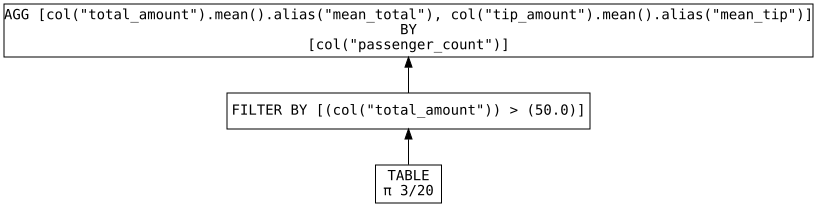

In [18]:
lazy_query.show_graph()

In [19]:
results = lazy_query.collect()
results

passenger_count,mean_total,mean_tip
i64,f64,f64
null,63.9289,2.542478
0,82.067988,10.371677
3,87.961587,10.202058
7,99.81,7.0
1,81.479145,10.351867
8,103.275,14.025
2,90.83368,10.612527
6,81.968523,10.260538
5,80.993877,10.31949


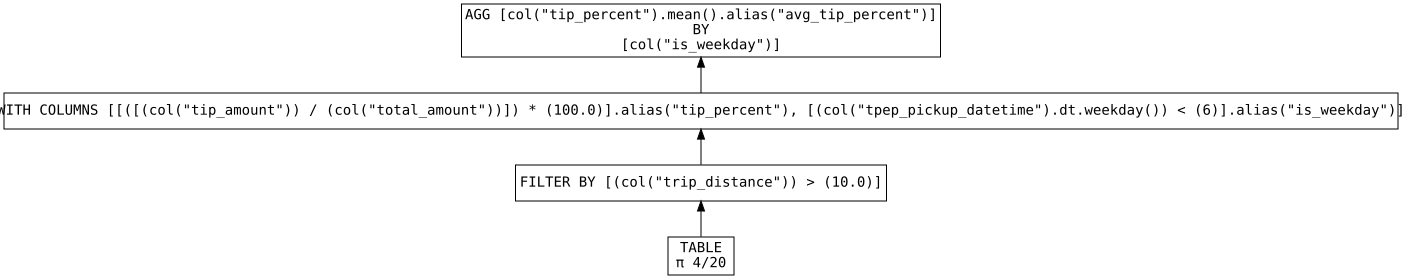

is_weekday,avg_tip_percent
bool,f64
false,NaN
true,NaN


In [20]:
complex_lazy_query = (lazy_df
    .filter(pl.col('trip_distance') > 10)
    .with_columns(
        tip_percent=tip_percent_expr
    )
    .with_columns(
        is_weekday=pl.col('tpep_pickup_datetime').dt.weekday() < 6
    )
    .group_by('is_weekday')
    .agg([
        pl.col('tip_percent').mean().alias('avg_tip_percent')
    ])
)

# Show the query plan
complex_lazy_query.show_graph()

# Execute and show results
results = complex_lazy_query.collect()
results

In [21]:
import time

# Eager mode
start = time.time()
eager_result = (df
    .filter(pl.col('total_amount') > 50)
    .select(['trip_distance', 'total_amount', 'tip_amount', 'passenger_count'])
    .group_by('passenger_count')
    .agg([
        pl.col('total_amount').mean().alias('mean_total'),
        pl.col('tip_amount').mean().alias('mean_tip')
    ])
)
eager_time = time.time() - start
print(f"Eager mode: {eager_time:.4f} seconds")

# Lazy mode
start = time.time()
lazy_result = (lazy_df
    .filter(pl.col('total_amount') > 50)
    .select(['trip_distance', 'total_amount', 'tip_amount', 'passenger_count'])
    .group_by('passenger_count')
    .agg([
        pl.col('total_amount').mean().alias('mean_total'),
        pl.col('tip_amount').mean().alias('mean_tip')
    ])
    .collect()
)
lazy_time = time.time() - start
print(f"Lazy mode: {lazy_time:.4f} seconds")

print(f"Lazy mode is {eager_time / lazy_time} times faster than eager mode")

Eager mode: 0.0174 seconds
Lazy mode: 0.0120 seconds
Lazy mode is 1.4522520011150493 times faster than eager mode


3a. I converted the dataframe to LazyFrame using .lazy() and displayed it using the sample code given in the question. 

3b. I built a lazy query with filter/select/group_by/agg operations, showing the query plan with .show_graph() using the sample code given in the question. 

3c. I executed the lazy query with .collect() and displayed the results using the sample code given in the question. 

3d. I created a complex lazy query with weekday grouping (using dt.weekday()), showing both the query plan and final results using the sample code given in the question. 

3e. See output above for the code timing of eager vs lazy execution of the same operations. From the output, we can see that lazy mode is about 1.45 times faster than the eager mode. This is because Polars have the ability to optimize the entire query (e.g., pushing filters down, eliminating unnecessary columns early, etc.). Hence, Polars rearranges operations to be more efficient in the lazy mode, which is why lazy mode is able to complete the same task as the eager mode in lesser time. 

## Question 4

In [22]:
lazy_df = pl.scan_parquet('/anvil/projects/tdm/data/taxi/yellow_2025/yellow_tripdata_2025-09.parquet')
lazy_df

In [23]:
streaming_query = (lazy_df
    .filter(pl.col('total_amount') > 100)
    .select(['trip_distance', 'total_amount', 'tip_amount', 'passenger_count'])
    .group_by('passenger_count')
    .agg([
        pl.col('total_amount').mean().alias('mean_total'),
        pl.len().alias('count_of_trips')
    ])
)
streaming_query

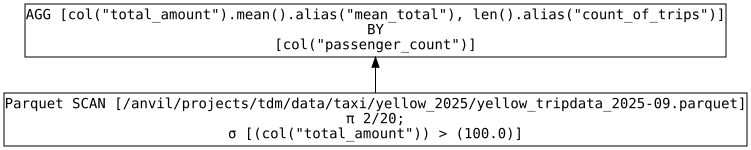

In [24]:
streaming_query.show_graph()

In [25]:
results = streaming_query.collect(engine='streaming')
results

passenger_count,mean_total,count_of_trips
i64,f64,u32
null,121.500072,1656
4,129.47427,3220
2,144.674311,13274
3,126.489718,2804
6,119.616226,106
1,125.570044,44680
5,117.678592,206
8,108.3,1
0,131.006488,299


In [26]:
import time

# Non-streaming (regular lazy evaluation)
start = time.time()
non_streaming_result = streaming_query.collect()
non_streaming_time = time.time() - start
print(f"Non-streaming: {non_streaming_time:.4f} seconds")

# Streaming
start = time.time()
streaming_result = streaming_query.collect(engine='streaming')
streaming_time = time.time() - start
print(f"Streaming: {streaming_time:.4f} seconds")

print(f"Streaming mode is {non_streaming_time / streaming_time} times faster than non-streaming mode")

Non-streaming: 0.0110 seconds
Streaming: 0.0104 seconds
Streaming mode is 1.0543754726060357 times faster than non-streaming mode


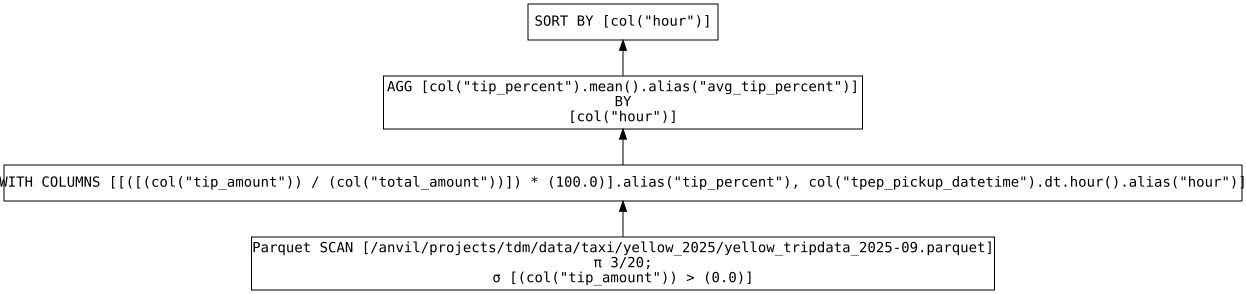

hour,avg_tip_percent
i8,f64
0,14.98392
1,14.986267
2,14.943207
3,15.162271
4,15.238544
…,…
19,15.114451
20,15.279539
21,15.329872


In [27]:
complex_streaming_query = (lazy_df
    .filter(pl.col('tip_amount') > 0)
    .with_columns(
        tip_percent=tip_percent_expr
    )
    .with_columns(
        hour=pl.col('tpep_pickup_datetime').dt.hour()
    )
    .group_by('hour')
    .agg([
        pl.col('tip_percent').mean().alias('avg_tip_percent')
    ]).sort('hour')
)

# Show the query plan
complex_streaming_query.show_graph()

# Execute and show results
results = complex_streaming_query.collect(engine='streaming')
results

4a. I used scan_parquet() to create a LazyFrame and displayed it using the sample code in the question. 

4b. I wrote the code for creating a streaming query with filter/select/group_by/agg operations, executed it with .collect(engine='streaming') and displayed the results. I used ChatGPT to check my code. I realized that to calculate the count of trips, I did not need to depend on a specific column and instead used pl.len() directly. Before executing the results, I also used the show_graph() to show the query plan. 

4c. I compared streaming vs non-streaming execution times for the same query using the sample code given in the question. Based on my output, the streaming mode is about 1.05 times faster than the non-streaming mode. 

4d. I wrote the code for creating a complex streaming query analyzing tip percentage by hour (using dt.hour()), with results sorted by hour. I used ChatGPT to check my code and found that my logic when writing this code was correct. I have displayed both the query plan and the results. The results show the average tip percent sorted by hour in ascending order. 

4e. Streaming is a feature of Polars that allows it to process data in chunks rather than loading everything into memory at once. It is useful when your dataset is larger than your available RAM or when you want to reduce memory usage. Hence, streaming is essential for datasets larger than available RAM and that is when it is the most applicable. Regular lazy evaluation is best applicable when you are not worried about your memory usage and can load all the data into memory without crashing. However, in large datasets, it is not possible to load and process all the data at once without crashing and hence, streaming becomes essential when dealing with these large datasets. One possible drawback of streaming is that it might even be slightly slower because of the overhead of processing in chunks. However, in our example above for part 4c, streaming was faster. But this may not be true when dealing with very large datasets. 

## Question 5

In [28]:
df = pl.read_parquet('/anvil/projects/tdm/data/taxi/yellow_2025/yellow_tripdata_2025-09.parquet')
print(f"Estimated size: {df.estimated_size() / 1024 / 1024:.2f} MB")
print("\nSchema:")
print(df.schema)

Estimated size: 571.14 MB

Schema:
Schema({'VendorID': Int32, 'tpep_pickup_datetime': Datetime(time_unit='us', time_zone=None), 'tpep_dropoff_datetime': Datetime(time_unit='us', time_zone=None), 'passenger_count': Int64, 'trip_distance': Float64, 'RatecodeID': Int64, 'store_and_fwd_flag': String, 'PULocationID': Int32, 'DOLocationID': Int32, 'payment_type': Int64, 'fare_amount': Float64, 'extra': Float64, 'mta_tax': Float64, 'tip_amount': Float64, 'tolls_amount': Float64, 'improvement_surcharge': Float64, 'total_amount': Float64, 'congestion_surcharge': Float64, 'Airport_fee': Float64, 'cbd_congestion_fee': Float64})


In [29]:
lazy_df = df.lazy()

optimized_query = (lazy_df
    .filter(pl.col('total_amount') > 30)
    .with_columns(
        tip_percent=tip_percent_expr
    )
    .filter(pl.col('tip_percent') > 15)
    .group_by('passenger_count')
    .agg([
        pl.len().alias('trip_count'),
        pl.col('total_amount').mean().alias('mean_total'),
        pl.col('tip_percent').mean().alias('mean_tip_percent')
    ])
)

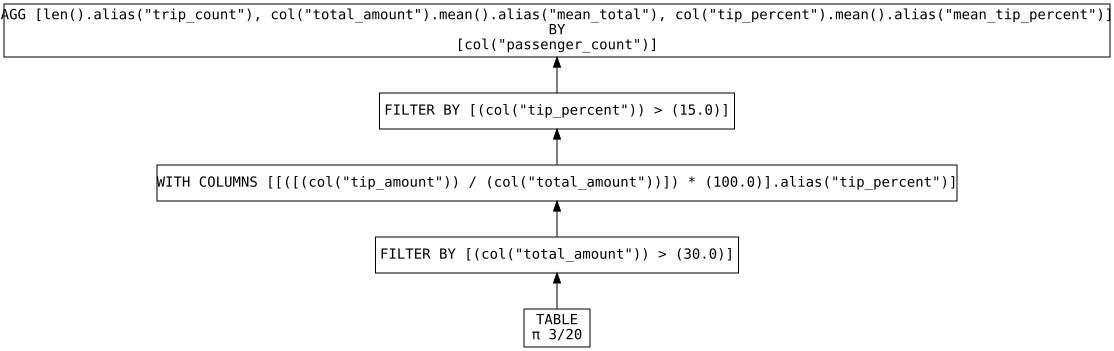

In [30]:
optimized_query.show_graph()

In [31]:
COST_COLS = [
    "fare_amount",
    "extra",
    "tip_amount",
    "improvement_surcharge",
    "congestion_surcharge",
    "Airport_fee",
    "cbd_congestion_fee"
]

import time

# Polars Eager Version
start = time.time()
cost_breakdown = df.select(
    pl.col("total_amount").alias("total"),
    *[
        (pl.col(c) / pl.col("total_amount") * 100).alias(f"{c}_percent")
        for c in COST_COLS
    ]
)
eager_time = time.time() - start
print(f"Polars time (eager): {eager_time:.4f} seconds")
print(f"Shape: {cost_breakdown.shape}")


# Polars Lazy Version
start = time.time()
cost_breakdown = lazy_df.select(
    pl.col("total_amount").alias("total"),
    *[
        (pl.col(c) / pl.col("total_amount") * 100).alias(f"{c}_percent")
        for c in COST_COLS
    ]
)
results = cost_breakdown.collect()
lazy_time = time.time() - start
print(f"Polars time (lazy): {lazy_time:.4f} seconds")
print(f"Shape: {results.shape}")

Polars time (eager): 0.0121 seconds
Shape: (4251015, 8)
Polars time (lazy): 0.0098 seconds
Shape: (4251015, 8)


In [32]:
import pandas as pd

# Read the data
pandas_df = pd.read_parquet('/anvil/projects/tdm/data/taxi/yellow_2025/yellow_tripdata_2025-09.parquet')

start = time.time()
pandas_cost_breakdown = pd.DataFrame()
pandas_cost_breakdown['total'] = pandas_df['total_amount']
for c in COST_COLS:
    pandas_cost_breakdown[f'{c}_percent'] = (pandas_df[c] / pandas_df['total_amount']) * 100
pandas_time = time.time() - start
print(f"Pandas time: {pandas_time:.4f} seconds")
print(f"Shape: {pandas_cost_breakdown.shape}")

Pandas time: 0.1977 seconds
Shape: (4251015, 8)


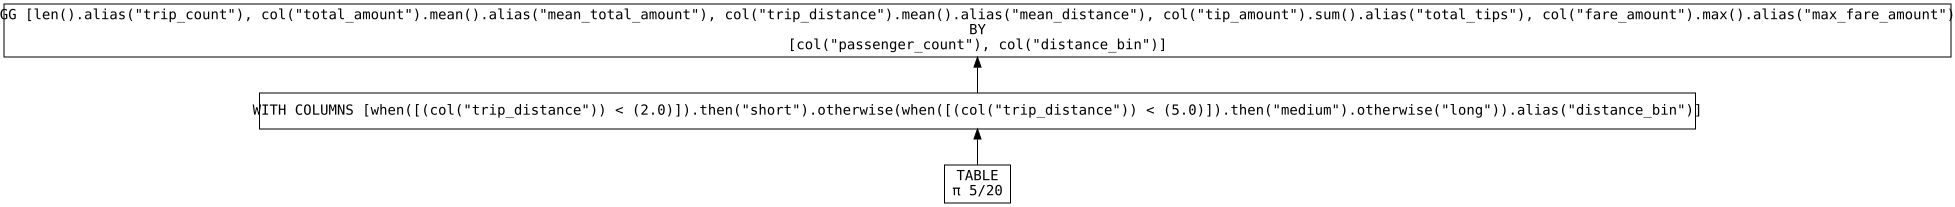

In [33]:
parallel_query = (lazy_df
    .with_columns(
        distance_bin=pl.when(pl.col('trip_distance') < 2)
            .then(pl.lit('short'))
            .when(pl.col('trip_distance') < 5)
            .then(pl.lit('medium'))
            .otherwise(pl.lit('long'))
    )
    .group_by(['passenger_count', 'distance_bin'])
    .agg([
        pl.len().alias('trip_count'),
        pl.col('total_amount').mean().alias('mean_total_amount'),
        pl.col('trip_distance').mean().alias('mean_distance'),
        pl.col('tip_amount').sum().alias('total_tips'),
        pl.col('fare_amount').max().alias('max_fare_amount')
    ])
)

parallel_query.show_graph()

In [34]:
results = parallel_query.collect(engine='streaming')
results

passenger_count,distance_bin,trip_count,mean_total_amount,mean_distance,total_tips,max_fare_amount
i64,str,u32,f64,f64,f64,f64
null,"""long""",259978,34.322816,62.254695,108815.86,512.47
5,"""short""",7268,18.190076,1.139312,17495.89,130.0
6,"""long""",902,69.807583,11.917672,7631.65,235.4
0,"""long""",2469,66.261989,10.479469,20801.87,278.1
5,"""medium""",3446,29.040972,2.97085,13497.98,119.2
…,…,…,…,…,…,…
1,"""short""",1458228,17.98535,1.087211,3.5230e6,900.0
3,"""medium""",23130,28.500968,3.000297,84126.72,121.0
2,"""long""",92264,74.259462,12.931994,819439.33,323800.27


5a. I wrote the code to check memory usage with .estimated_size() and displaying schema with .schema attribute using the sample code given in the question. However, the sample code gave me an error upon running because I realized, with ChatGPT's help, that the full path to the dataset was not defined and I fixed that using the codes in the previous questions so that the code would work. Then, ACF (Apache Arrow’s Columnar Format) is one of the underlying technology that makes Polars very fast. To begin with, Apache Arrow uses a columnar memory format. It is different from row-based storage because data is stored column-by-column where data for each column is stored in contiguous memory blocks. This means that the data for each column is stored together in order in memory. It allows zero-copy sharing because Arrow Columnar Format (ACF) is a standardized memory format that many libraries can use. Some of these libraries are Polars, PyArrow, DuckDB, etc which all have the same memory format. 

5b. I created a complex lazy query with multiple filters and aggregations, showing the optimized query plan with .show_graph(). Based on the query plan output, the types of optimizations that I can see can be classified into predicate pushdown and projection pushdown. For example, I see that filters are pushed down to happen earlier, only the necessary columns are selected, and multiple operations are combined together as seen in the aggregations part. 

5c. I wrote the code for performing transformations for all cost columns, with time calculated in both the eager and lazy modes. I also repeated the same in pandas to compare the times. My Pandas code crashed since this dataset was huge so I restarted my anvil session with a greater number of cores to be able to process the results and get the output. Based on the results I foung that lazy mode is faster than the eager mode and Polars, in general, does a better job at performing the same transformation when compared to Pandas because it is significantly faster. This is because Polars can process different columns in parallel since they are stored separately in memory. Hence, even the eager mode is faster than Pandas because it can parallelize all the operations in memory. However, Pandas cannot do this, making it much slower.   

5d. I wrote the code for creating a query grouping by multiple columns (passenger_count and distance_bin) and showed the query plan along with the results. I used ChatGPT to check my code and found that my code logic was correct and made some minor changes such as labeling the 'length_of_trips' to 'trip_count' for better understanding. Furthermore, columnar format enables parallelization because these columns are stored separately in memory (columnar format), and Polars can process these aggregations simultaneously on different CPU cores. However, this is difficult to achieve in row-based storage like in Pandas because all the data for a row is stored together, making it difficult to process different columns independently and in parallel. 

5e. Some of the key reasons why Polars is faster is because it uses a standardized memory format called the ACF that stores its data in a columnar format, allows for query optimization through predicate and projection pushdowns, enables parallelization since all the data is stored in columnar format, and enables a faster query engine because it can process multiple aggregations simultaneously on different CPU cores and also process data in chunks rather than load everything into the memory at once. Hence, Polars are the most effective when dealing with large datasets (larger than your available RAM), and limited memory usage. This is because given Polars' benefits when compared to Pandas, it would effectively help analyze these large datasets in shorter time and will not crash if the CPU cores are less. 

## Pledge

By submitting this work I hereby pledge that this is my own, personal work. I've acknowledged in the designated place at the top of this file all sources that I used to complete said work, including but not limited to: online resources, books, and electronic communications. I've noted all collaboration with fellow students and/or TA's. I did not copy or plagiarize another's work.

> As a Boilermaker pursuing academic excellence, I pledge to be honest and true in all that I do. Accountable together – We are Purdue.

https://www.purdue.edu/odos/osrr/honor-pledge/
